importing the dataset

In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import warnings 
warnings.filterwarnings('ignore')
import  scipy.stats as stats
import seaborn as sns

import requests
from bs4 import BeautifulSoup
import pandas as pd
import time

In [2]:
data=pd.read_csv("DiamondPricesData.csv")

In [3]:
data.describe(include="all")

,price,carat,cut,color,clarity,depth,table,x,y,z
count,53940.000000,53940.000000,53940,53934,53940,53926.000000,53940.000000,53940.000000,53940.000000,53940.000000
unique,NaN,NaN,5,7,8,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,Ideal,G,SI1,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,21551,11286,13065,NaN,NaN,NaN,NaN,NaN
mean,3932.799722,0.797940,NaN,NaN,NaN,61.749479,57.457184,5.731157,5.734526,3.538734
std,3989.439738,0.474011,NaN,NaN,NaN,1.432661,2.234491,1.121761,1.142135,0.705699
min,326.000000,0.200000,NaN,NaN,NaN,43.000000,43.000000,0.000000,0.000000,0.000000
25%,950.000000,0.400000,NaN,NaN,NaN,61.000000,56.000000,4.710000,4.720000,2.910000
50%,2401.000000,0.700000,NaN,NaN,NaN,61.800000,57.000000,5.700000,5.710000,3.530000
75%,5324.250000,1.040000,NaN,NaN,NaN,62.500000,59.000000,6.540000,6.540000,4.040000


In [4]:
data.duplicated().sum()

np.int64(146)

In [5]:
data=data.drop_duplicates()

In [7]:
data.dtypes

price        int64
carat      float64
cut         object
color       object
clarity     object
depth      float64
table      float64
x          float64
y          float64
z          float64
dtype: object

In [6]:
data.isnull().sum()

price       0
carat       0
cut         0
color       6
clarity     0
depth      14
table       0
x           0
y           0
z           0
dtype: int64

In [11]:
data["color"].fillna(0)

0        E
1        E
2        E
3        I
4        J
        ..
53935    D
53936    D
53937    D
53938    H
53939    D
Name: color, Length: 53794, dtype: object

In [12]:
data.isna().sum()

price       0
carat       0
cut         0
color       6
clarity     0
depth      14
table       0
x           0
y           0
z           0
dtype: int64

In [9]:
data.fillna(method="ffill",inplace=True)

In [ ]:
#Imputation with Mean


numeric_cols = ['DSC3108', 'DSC3114']  # Only these have missing numerics
for col in numeric_cols:
  data[col] = data[col].fillna(data[col].mean())

# Impute categorical column with mode
categorical_cols = ['course']
for col in categorical_cols:
    mode_val =data[col].mode()[0]  # Most frequent value
    data[col] = data[col].fillna(mode_val)


In [ ]:
# Interpolate numeric columns linearly (bidirectional by default in Pandas)
numeric_cols = ['DSC3108', 'DSC3114']
data[numeric_cols] = data[numeric_cols].interpolate(method='linear', limit_direction='both')

# Forward fill categorical column
categorical_cols = ['course']
data[categorical_cols] = data[categorical_cols].ffill()

In [ ]:

# Backward fill all columns with missing values
df_bfill = data.bfill()

In [ ]:
df_dropped = data.dropna()

In [10]:
data.isnull().sum()

price      0
carat      0
cut        0
color      0
clarity    0
depth      0
table      0
x          0
y          0
z          0
dtype: int64

In [ ]:
# web scraping
headers = {"User-Agent": "Mozilla/5.0 (Kisakye Maria - Student)"}

def scrape_books_page(page_num):
    url = f"http://books.toscrape.com/catalogue/page-{page_num}.html"
    try:
        response = requests.get(url, headers=headers, timeout=10)
        if response.status_code != 200:                 
            print(f"Failed page {page_num}: {response.status_code}")
            return []
        soup = BeautifulSoup(response.text, 'html.parser')
        books = soup.find_all('article', class_='product_pod')
        data = []
        for book in books:
            title = book.h3.a['title']
            price = book.find('p', class_='price_color').get_text()
            rating = book.find('p', class_='star-rating')['class'][1]
            avail = book.find('p', class_='instock availability').get_text(strip=True)
            data.append({'title': title, 'price': price, 'rating': rating, 'availability': avail})
        return data
    except Exception as e:
        print(f"Error on page {page_num}: {e}")
        return []

In [ ]:
all_books = []     

In [ ]:
for page in range(1, 51):
    print(f"Scraping page {page}/50...")
    all_books.extend(scrape_books_page(page))          #extend adds multiple items to the list
    time.sleep(0.5)

print(f"\nCollected {len(all_books)} books")

In [ ]:
df_raw = pd.DataFrame(all_books)
df_raw.to_excel("books_kisakye.xlsx", index=False)     #index=False to avoid adding index column
print("Raw data saved as 'books_kisakye.xlsx'")
df_raw.head()

In [ ]:
cont_data=data.select_dtypes(include=["int64","float64"])

In [ ]:
cont_data=data.select_dtypes(include=["int64","float64"])

(array([[<Axes: title={'center': 'price'}>,
         <Axes: title={'center': 'carat'}>,
         <Axes: title={'center': 'depth'}>],
        [<Axes: title={'center': 'table'}>, <Axes: title={'center': 'x'}>,
         <Axes: title={'center': 'y'}>],
        [<Axes: title={'center': 'z'}>, <Axes: >, <Axes: >]], dtype=object),
 <Figure size 1000x1000 with 0 Axes>)

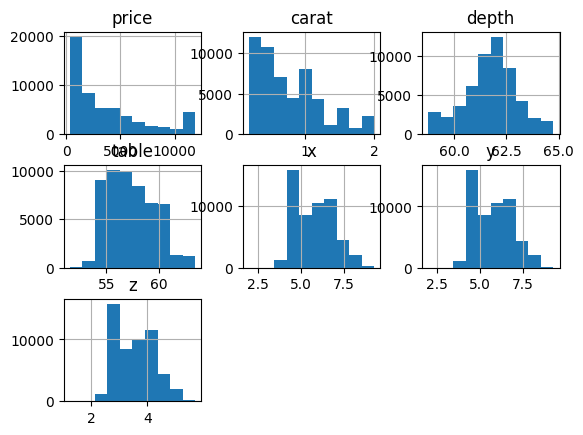

<Figure size 1000x1000 with 0 Axes>

In [21]:
cont_data.hist(["price","carat","depth","table","x","y","z"]), plt.figure(figsize=(10,10))

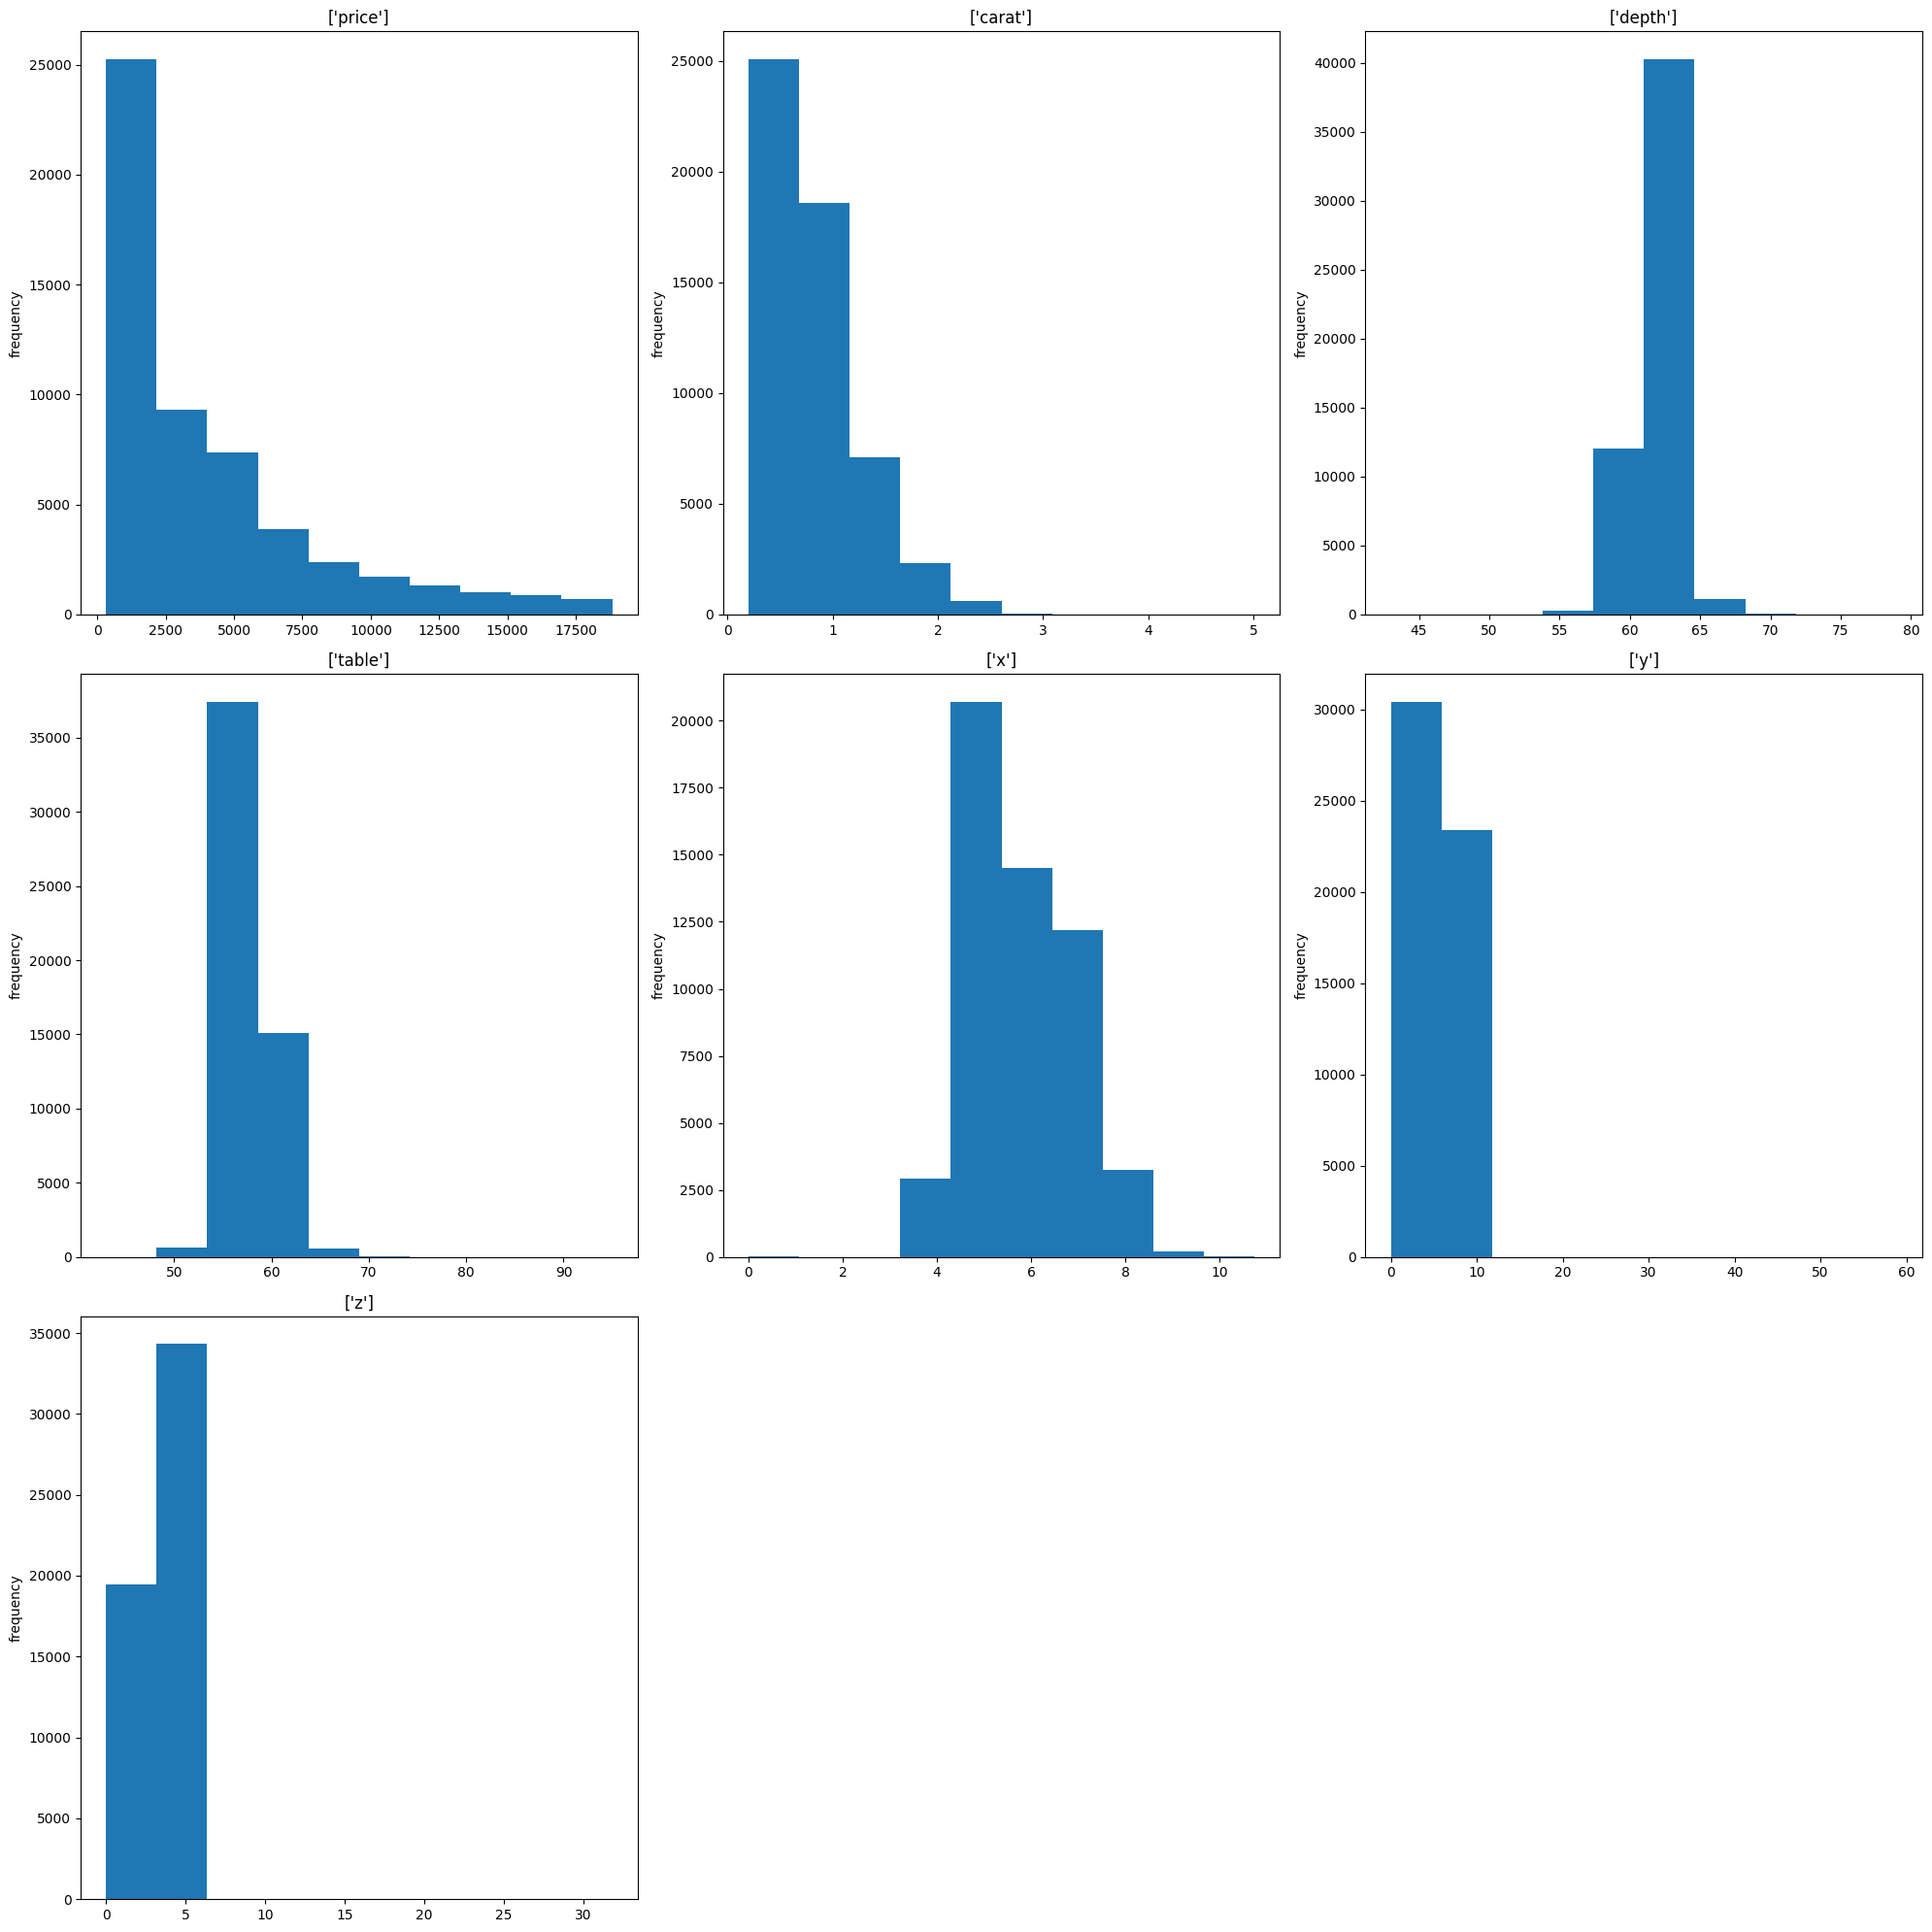

In [13]:

plt.figure(figsize=(20,20))
for i,col in enumerate(cont_data):
   plt.subplot(3,3,i+1)
   plt.hist(data[col])
   plt.title([col])
   plt.ylabel(f"frequency")
plt.tight_layout()
plt.show()



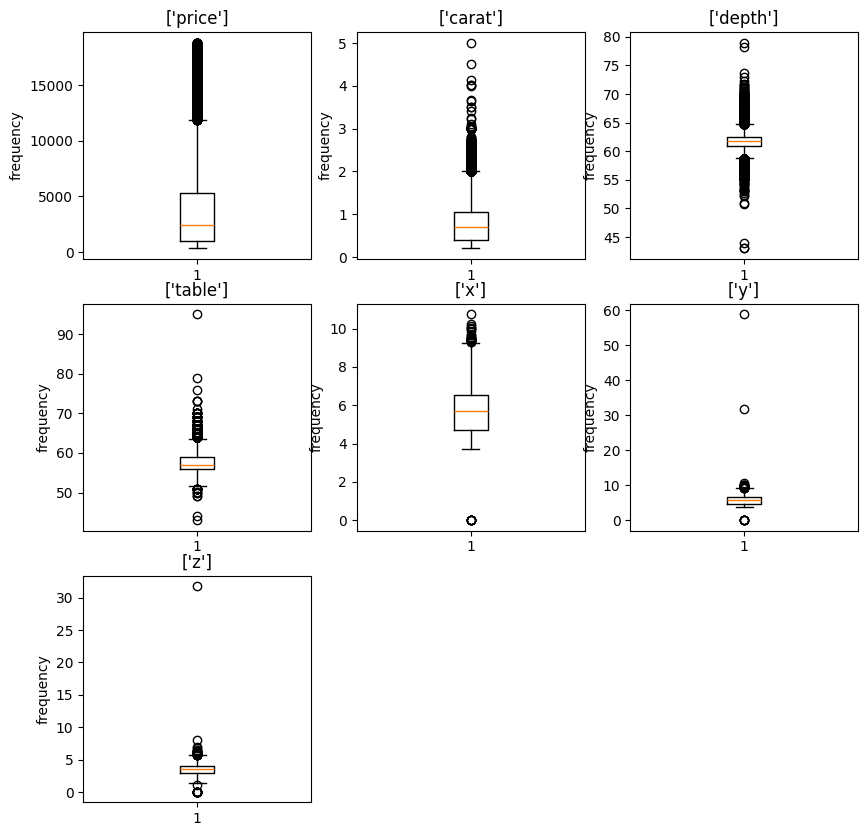

In [ ]:
plt.figure(figsize=(10,10))
for i, col, in enumerate(cont_data):
    plt.subplot(3, 3, i+1)
    plt.boxplot(data[col])
    plt.title([col])
    plt.ylabel(f"frequency")
plt.tight_layout
plt.show()

In [15]:
def remove_outliers(columns):
    for column in columns:
        Q3=cont_data[column].quantile(0.75)
        Q1=cont_data[column].quantile(0.25)
        IQR=Q3-Q1
        upper=Q3 + 1.5*IQR
        lower=Q1 - 1.5*IQR
        cont_data[column]=np.where(cont_data[column]>upper,upper,cont_data[column])
        cont_data[column]=np.where(cont_data[column]<lower,lower,cont_data[column])

In [16]:
remove_outliers(["price","carat","depth", "table","x","y","z"])

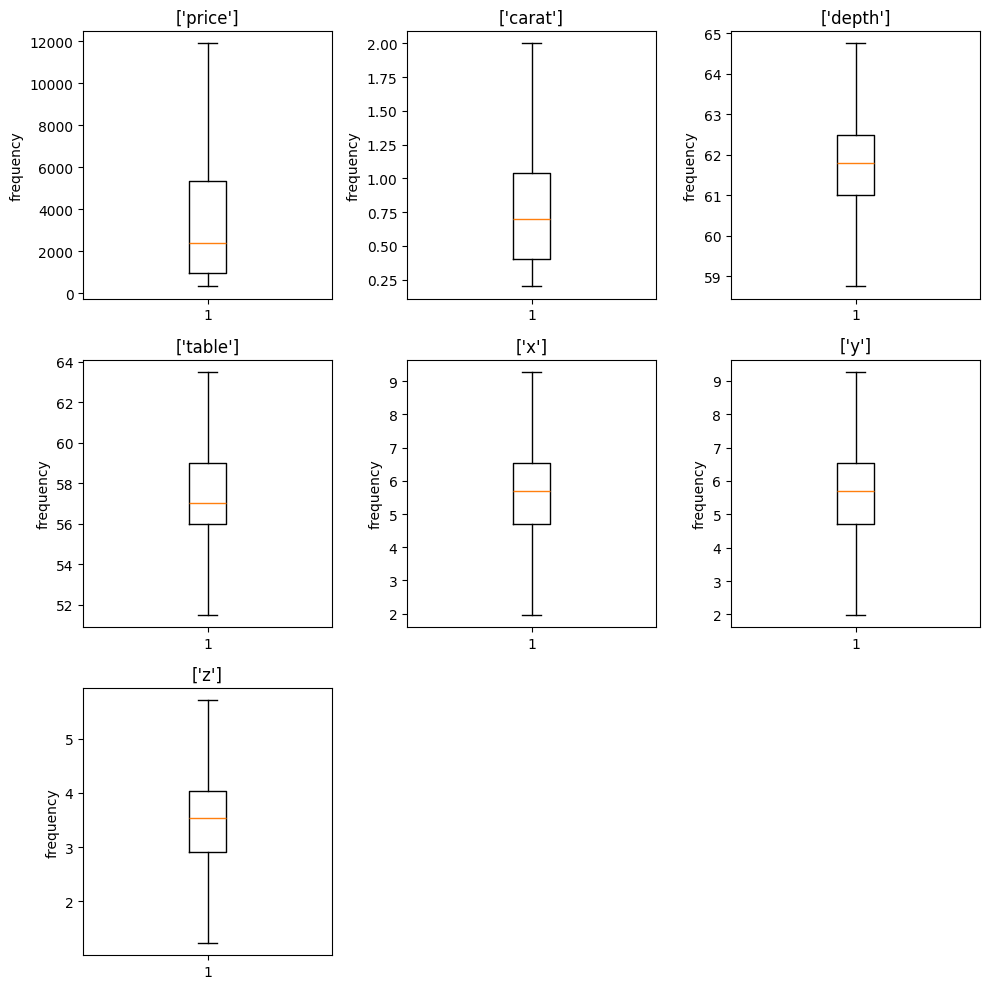

In [17]:
plt.figure(figsize=(10,10))
for i, col in enumerate(cont_data):
    plt.subplot(3,3,i+1)
    plt.boxplot(cont_data[col])
    plt.title([col])
    plt.ylabel(f"frequency")
plt.tight_layout()
plt.show()

In [ ]:
#distribution of one variable
# ---- Price distribution ----
plt.figure(figsize=(8,5))
plt.hist(data["Price"], color="#1daa1f", edgecolor="black")
plt.title("Distribution of Book Prices")
plt.xlabel("Price (£)")
plt.ylabel("Number of books")
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
# count plots
# ---- Rating counts ----
rating_counts = data["Rating"].value_counts().sort_index()
plt.figure(figsize=(7,5))
rating_counts.plot(kind="bar", color="#f28e2b")
plt.title("Number of Books per Rating")
plt.xlabel("Rating (1-5)")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.grid(True, alpha=0.3)
plt.show()

RELATIONSHIPS btwn cont and cont
Stastical relation ship

<Axes: >

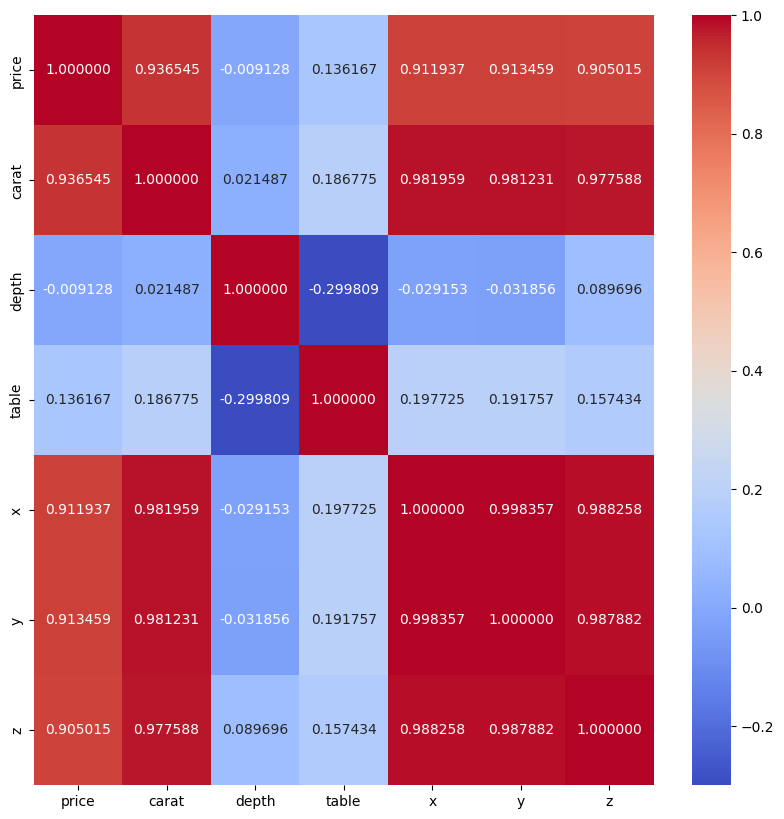

In [18]:
corr_matrix=cont_data.corr()
corr_matrix
plt.figure(figsize=(10,10))
sns. heatmap(corr_matrix ,annot=True, cmap="coolwarm",fmt='3f')


Visualization Relationship btwn cont vs cont

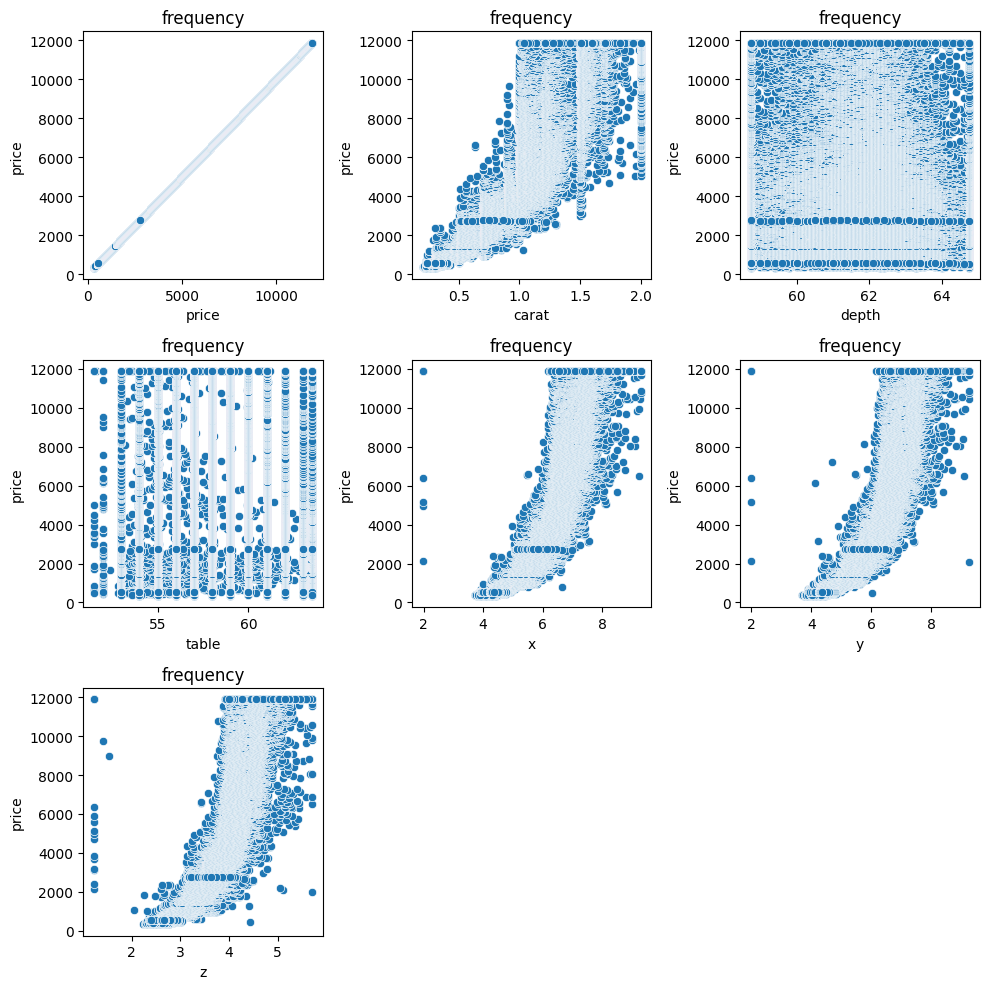

In [19]:
plt.figure(figsize=(10,10))
for i, col in enumerate(cont_data.columns):
    plt.subplot(3,3,i+1)
    sns.scatterplot(cont_data, y="price",x=col)
    plt.title(f"frequency")
plt.tight_layout()
plt.show()

RELATIONSHIP CONT VS CAT VISUALIZATION 

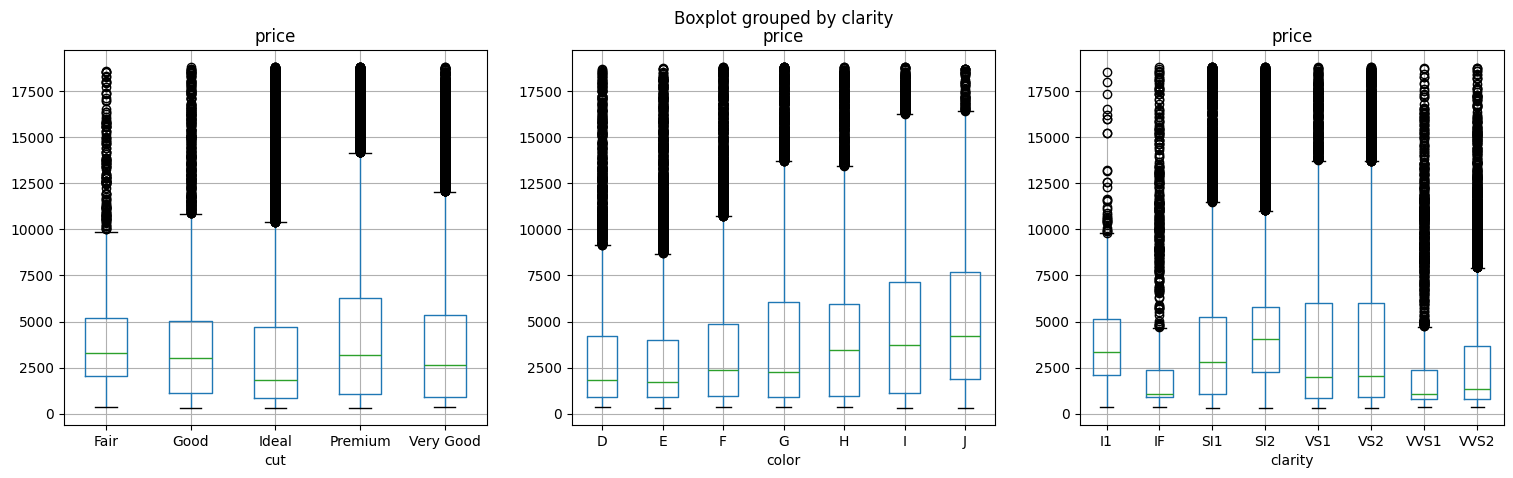

In [20]:
CategoricalColsList=['cut', 'color', 'clarity']

import matplotlib.pyplot as plt
fig, PlotCanvas=plt.subplots(nrows=1, ncols=len(CategoricalColsList), figsize=(18,5))

# Creating box plots for each continuous predictor against the Target Variable "price"
for PredictorCol , i in zip(CategoricalColsList, range(len(CategoricalColsList))):
    data.boxplot(column='price', by=PredictorCol, figsize=(5,5), vert=True, ax=PlotCanvas[i])

statistical relationship of cat vs cont (Anova test)


In [23]:
def Anova_test (inpData,TargetVariable,CategoricalColsList ):
    from scipy.stats import f_oneway
    SelectedPredictors=[]
    print("###AnovaResults###\n")
 
    for predictor in CategoricalColsList:
        grouplist=inpData.groupby(predictor)[TargetVariable].apply(list)
        AnovaResult=f_oneway(*grouplist)
        if AnovaResult[1]<0.05:
            print("Predictor","is correlated with","Target variable","/p_Value:",AnovaResult[1])
            SelectedPredictors.append(predictor)
        else:
            print("predictor","is Not is correlated with","Target Variable","/p_Value",AnovaResult[1])
        return CategoricalColsList

Stastictical Relationship Between CAT VS CAT

In [ ]:
Crosstabresult=pd.crosstab(index=cat_data["cut"],columns=cat_data["clarity"])
print(Crosstabresult)



In [ ]:
from scipy.stats import chi2_contingency
Chi2Results=chi2_contingency(Crosstabresult)
print('The P-valueof the chi_test is:', Chi2Results)

VISUALIZATION OF THE BARPLOT

In [ ]:
Crosstabresult.plot.bar()

In [24]:
cat_data

,cut,color,clarity
0,Ideal,E,SI2
1,Premium,E,SI1
2,Good,E,VS1
3,Premium,I,VS2
4,Good,J,SI2
...,...,...,...
53935,Ideal,D,SI1
53936,Good,D,SI1
53937,Very Good,D,SI1
53938,Premium,H,SI2


In [26]:
CategoricalColsList=["color","clarity","cut"]
Anova_test(inpData=data,
           TargetVariable="price",
           CategoricalColsList=CategoricalColsList
           

)



###AnovaResults###

Predictor is correlated with Target variable /p_Value: 0.0


['color', 'clarity', 'cut']

In [ ]:
#Calculate covariance the shorter way
covariance2 = data['Profit'].cov(data['Revenue'])

# Print the result
print("Covariance between Profit and Revenue:", covariance2)

In [27]:
data["cut"].unique()

array(['Ideal', 'Premium', 'Good', 'Very Good', 'Fair'], dtype=object)

encode the data befor you build a a model

In [37]:
data["cut"].replace(["Ideal","Premium","Good","Very Good","Fair"],[0,1,2,3,4], inplace=True)



In [44]:
data["clarity"].unique()

array([0, 1, 2, 'VS2', 3, 4, 5, 6], dtype=object)

In [45]:
data["clarity"].replace(["VS2"],[7], inplace=True)

In [40]:
data["color"].unique()

array([0, 1, 2, 3, 4, 5, 6])

In [32]:
data["color"].replace(["E","I","J","H","F","D","G"],[0,1,2,3,4,5,6],inplace=True)

split the data into x and y

In [46]:
corr_matrix=data.corr()
corr_matrix

,price,carat,cut,color,clarity,depth,table,x,y,z
price,1.000000,0.921548,0.048440,-0.002554,-0.077119,-0.011067,0.126566,0.884504,0.865395,0.861208
carat,0.921548,1.000000,0.113239,-0.050229,-0.181972,0.027836,0.181091,0.975380,0.951908,0.953542
cut,0.048440,0.113239,1.000000,-0.033532,-0.088828,0.168911,0.382209,0.104314,0.104302,0.125560
color,-0.002554,-0.050229,-0.033532,1.000000,0.020006,0.001239,-0.038275,-0.040539,-0.040380,-0.041083
clarity,-0.077119,-0.181972,-0.088828,0.020006,1.000000,-0.020871,-0.080068,-0.192600,-0.188060,-0.189828
depth,-0.011067,0.027836,0.168911,0.001239,-0.020871,1.000000,-0.297580,-0.025381,-0.029422,0.094716
table,0.126566,0.181091,0.382209,-0.038275,-0.080068,-0.297580,1.000000,0.194855,0.183231,0.150270
x,0.884504,0.975380,0.104314,-0.040539,-0.192600,-0.025381,0.194855,1.000000,0.974592,0.970686
y,0.865395,0.951908,0.104302,-0.040380,-0.188060,-0.029422,0.183231,0.974592,1.000000,0.951844
z,0.861208,0.953542,0.125560,-0.041083,-0.189828,0.094716,0.150270,0.970686,0.951844,1.000000


In [47]:
X=data[["carat","x","y","z"]]
Y=data["price"]

SPLITTING THE DATA

In [ ]:
X_train, X_test, y_train, y_test=train_test_split(X,y, test_size=0.2, random_state=42)

In [ ]:
from sklearn.tree import DecisionTreeRegressor
decision_tree_model=DecisionTreeRegressor()
decision_tree_model.fit(X_train,y_train)

y_pred= decision_tree_model.predict(X_test)

from sklearn.metrics import r2_score,mean_squared_error,root_mean_squared_error
r2=r2_score(y_test, y_pred)
mse=mean_squared_error(y_test,y_pred)
rmse= root_mean_squared_error(y_test, y_pred)

print(f'r**2 score: {r2:.2f}')
print(f"Mean squared error:{mse:.3f}")
print(f'Root mean squared error:{rmse:.3f}')


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = DecisionTreeClassifier()
model.fit(X_train, y_train)

prediction = model.predict(X_test)
 
score = accuracy_score(y_test, prediction)
score

In [ ]:
import pickle

with open('Linear_model.pkl', 'wb') as file:
    pickle.dump(model,file) 